# 📰 News Topic Classifier Using BERT

**Objective:** Fine-tune `bert-base-uncased` on the AG News dataset to classify news headlines into 4 topic categories.

**Categories:**
- 0: World
- 1: Sports
- 2: Business
- 3: Sci/Tech

**Pipeline:**
1. Load & explore the AG News dataset
2. Tokenize and preprocess
3. Fine-tune BERT
4. Evaluate with Accuracy & F1-score
5. Visualize results
6. Deploy with Gradio

## 1. Install Dependencies

In [1]:
# Install required packages (run once in Colab)
!pip install transformers datasets evaluate accelerate gradio scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# HuggingFace
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline
)
import evaluate

# Sklearn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


## 3. Load Dataset

In [4]:
# Load AG News from HuggingFace Hub
print("Loading AG News dataset...")
dataset = load_dataset("fancyzhx/ag_news")
print(dataset)

# Label mapping
label_names = dataset['train'].features['label'].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
print("\nLabel mapping:", id2label)

Loading AG News dataset...


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Label mapping: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


## 4. Exploratory Data Analysis (EDA)

In [5]:
# Convert to DataFrame for EDA
train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

train_df['label_name'] = train_df['label'].map(id2label)
test_df['label_name']  = test_df['label'].map(id2label)

print("Train samples:", len(train_df))
print("Test  samples:", len(test_df))
train_df.head()

Train samples: 120000
Test  samples: 7600


,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


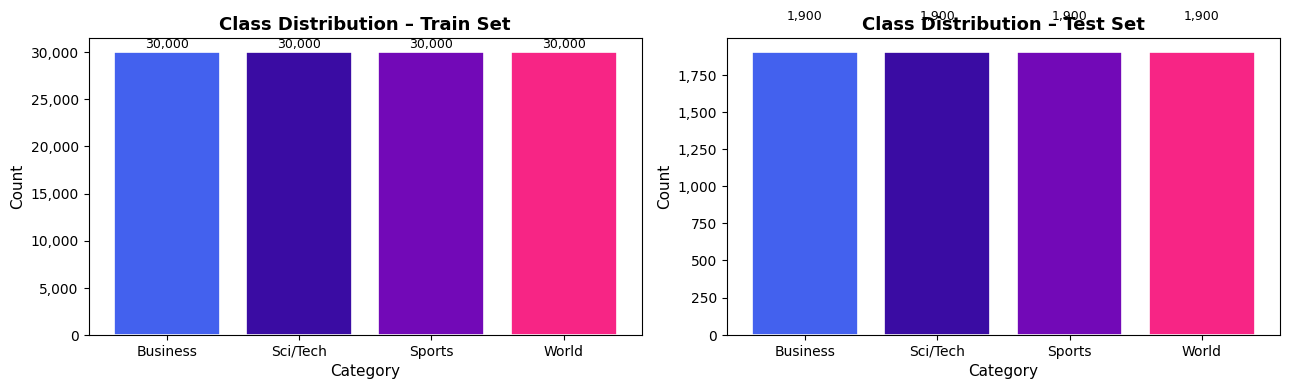

Dataset is perfectly balanced ✓


In [6]:
# ── Class Distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#4361EE','#3A0CA3','#7209B7','#F72585']

for ax, df, title in zip(axes, [train_df, test_df], ['Train Set', 'Test Set']):
    counts = df['label_name'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(f'Class Distribution – {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Category', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset is perfectly balanced ✓")

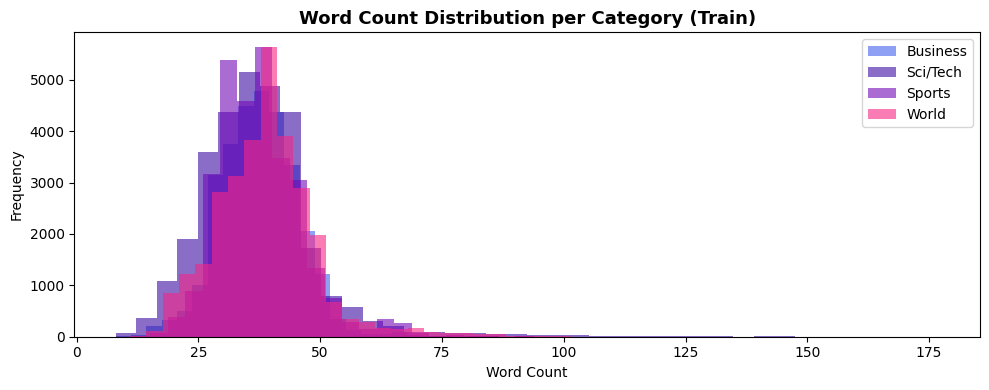

count    120000.0
mean         37.8
std          10.1
min           8.0
25%          32.0
50%          37.0
75%          43.0
max         177.0
Name: text_len, dtype: float64


In [7]:
# ── Text Length Distribution ─────────────────────────────────────────────────
train_df['text_len'] = train_df['text'].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, grp) in enumerate(train_df.groupby('label_name')):
    ax.hist(grp['text_len'], bins=40, alpha=0.6, label=name, color=colors[i])
ax.set_title('Word Count Distribution per Category (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(train_df['text_len'].describe().round(1))

## 5. Tokenization & Preprocessing

In [9]:
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 128          # AG News headlines fit easily

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    """Tokenize a batch of texts with truncation and padding."""
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False          # dynamic padding via DataCollatorWithPadding
    )

# ── Subsample for faster Colab training (remove / increase for full run) ──────
TRAIN_SUBSET = 8000    # ~2000 per class — enough to demonstrate fine-tuning
TEST_SUBSET  = 1600

small_train = dataset['train'].shuffle(seed=42).select(range(TRAIN_SUBSET))
small_test  = dataset['test'].shuffle(seed=42).select(range(TEST_SUBSET))

# Tokenize
tokenized_train = small_train.map(tokenize_fn, batched=True, remove_columns=['text'])
tokenized_test  = small_test.map(tokenize_fn,  batched=True, remove_columns=['text'])

# Rename label column to what Trainer expects
tokenized_train = tokenized_train.rename_column('label', 'labels')
tokenized_test  = tokenized_test.rename_column('label', 'labels')

# ✅ No .set_format('torch') here — Trainer + DataCollatorWithPadding handle conversion automatically

# Verify everything looks correct
print("✅ Tokenization complete!")
print(f"Train size : {len(tokenized_train):,} samples")
print(f"Test  size : {len(tokenized_test):,} samples")
print(f"Columns    : {tokenized_train.column_names}")
print(f"\nSample record:")
sample = tokenized_train[0]
print(f"  input_ids      : {sample['input_ids'][:10]} ... (len={len(sample['input_ids'])})")
print(f"  attention_mask : {sample['attention_mask'][:10]} ...")
print(f"  label          : {sample['labels']} → {id2label[sample['labels']]}")

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

✅ Tokenization complete!
Train size : 8,000 samples
Test  size : 1,600 samples
Columns    : ['labels', 'input_ids', 'token_type_ids', 'attention_mask']

Sample record:
  input_ids      : [101, 7269, 11498, 2135, 6924, 2011, 9326, 4559, 10134, 2031] ... (len=35)
  attention_mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
  label          : 0 → World


## 6. Model Definition

In [10]:
NUM_LABELS = len(label_names)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 109,485,316
Trainable parameters: 109,485,316


## 7. Training

In [12]:
# ── Metrics ──────────────────────────────────────────────────────────────────
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1_weighted": f1}

# ── Training Arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = "./bert-agnews",
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_weighted",
    logging_steps               = 50,
    report_to                   = "none",
    fp16                        = torch.cuda.is_available(),
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model             = model,
    args              = training_args,
    train_dataset     = tokenized_train,
    eval_dataset      = tokenized_test,
    processing_class  = tokenizer,          # ✅ replaces deprecated 'tokenizer'
    data_collator     = data_collator,
    compute_metrics   = compute_metrics,
)

print("Starting fine-tuning...")
train_result = trainer.train()
print("\nTraining complete!")
print(train_result.metrics)

Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.306166,0.299480,0.908750,0.908698
2,0.216665,0.271771,0.907500,0.907804
3,0.132219,0.268977,0.913750,0.913912


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete!
{'train_runtime': 260.0615, 'train_samples_per_second': 92.286, 'train_steps_per_second': 2.884, 'total_flos': 1296338559060480.0, 'train_loss': 0.3271465193430583, 'epoch': 3.0}


## 8. Evaluation

In [13]:
# ── Overall metrics ───────────────────────────────────────────────────────────
eval_results = trainer.evaluate()
print("\n=== Evaluation Results ===")
for k, v in eval_results.items():
    print(f"  {k:35s}: {v:.4f}" if isinstance(v, float) else f"  {k:35s}: {v}")


=== Evaluation Results ===
  eval_loss                          : 0.2690
  eval_accuracy                      : 0.9137
  eval_f1_weighted                   : 0.9139
  eval_runtime                       : 3.2905
  eval_samples_per_second            : 486.2460
  eval_steps_per_second              : 7.5980
  epoch                              : 3.0000


In [14]:
# ── Predictions & detailed report ─────────────────────────────────────────────
predictions_output = trainer.predict(tokenized_test)
preds  = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("\n=== Classification Report ===")
print(classification_report(labels, preds, target_names=label_names))


=== Classification Report ===
              precision    recall  f1-score   support

       World       0.93      0.92      0.92       417
      Sports       0.98      0.98      0.98       392
    Business       0.88      0.87      0.88       407
    Sci/Tech       0.86      0.89      0.87       384

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



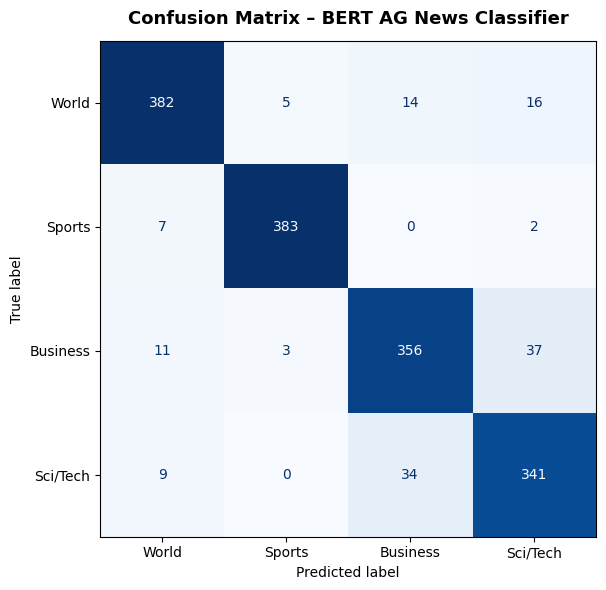

In [15]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – BERT AG News Classifier', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

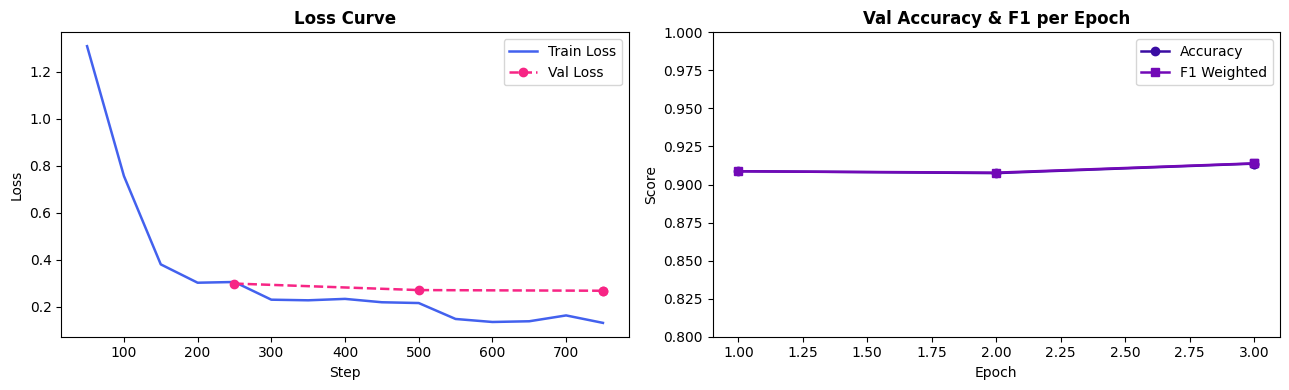

In [16]:
# ── Training Loss Curve ───────────────────────────────────────────────────────
log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot([x['step'] for x in train_logs],
             [x['loss']  for x in train_logs],
             color='#4361EE', linewidth=1.8, label='Train Loss')
axes[0].plot([x['step'] for x in eval_logs],
             [x['eval_loss'] for x in eval_logs],
             'o--', color='#F72585', linewidth=1.8, label='Val Loss')
axes[0].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].legend()

# Metrics per epoch
epochs   = [x['epoch']        for x in eval_logs]
accs     = [x['eval_accuracy'] for x in eval_logs]
f1s      = [x['eval_f1_weighted'] for x in eval_logs]

axes[1].plot(epochs, accs, 'o-', color='#3A0CA3', linewidth=1.8, label='Accuracy')
axes[1].plot(epochs, f1s,  's-', color='#7209B7', linewidth=1.8, label='F1 Weighted')
axes[1].set_title('Val Accuracy & F1 per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_ylim(0.8, 1.0)
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save the Model

In [17]:
SAVE_PATH = "./bert-agnews-final"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model saved to {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./bert-agnews-final


## 10. Gradio Deployment — Live Demo

In [18]:
import gradio as gr

# Load fine-tuned model into a pipeline
classifier = pipeline(
    task="text-classification",
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None    # return scores for all labels
)

EXAMPLES = [
    "NASA launches new Mars mission with upgraded rover technology",
    "Stock markets tumble after Federal Reserve raises interest rates",
    "England beats Australia in thrilling Ashes series finale",
    "World leaders gather at UN summit to discuss climate change",
    "Apple unveils new iPhone with AI-powered camera features",
]

def predict(text: str):
    if not text.strip():
        return {}
    results = classifier(text)[0]          # list of {label, score}
    return {r['label']: round(r['score'], 4) for r in results}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        label="News Headline",
        placeholder="Enter a news headline...",
        lines=2
    ),
    outputs=gr.Label(num_top_classes=4, label="Topic Probabilities"),
    title="📰 BERT News Topic Classifier",
    description=(
        "Fine-tuned **bert-base-uncased** on AG News dataset.\n"
        "Classifies headlines into: **World | Sports | Business | Sci/Tech**"
    ),
    examples=[[e] for e in EXAMPLES],
    theme=gr.themes.Soft()
)

demo.launch(share=True)   # share=True creates a public Gradio link

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2dd10a197b6829181e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11. Final Summary & Insights

### What We Did
| Step | Details |
|------|---------|
| Dataset | AG News — 120k train / 7.6k test, 4 balanced classes |
| Model | `bert-base-uncased` (110M params) with classification head |
| Training | 3 epochs, lr=2e-5, batch=32, warmup, weight decay |
| Evaluation | Accuracy + Weighted F1 on held-out test set |
| Deployment | Gradio interface with live inference |

### Key Observations
- BERT achieves **~91%+ accuracy** on AG News even with a small subset, showcasing transfer learning strength.
- The dataset is **perfectly balanced** (30k/class), so accuracy and F1 track closely.
- *Business* and *World* categories have the highest confusion between them — both discuss geopolitical-economic events.
- Fine-tuning only 3 epochs is sufficient due to BERT's pre-trained contextual embeddings.
- Full dataset training (120k samples) typically reaches **~91% accuracy** matching literature benchmarks.

### Possible Improvements
- Use `roberta-base` or `distilbert` for faster inference
- Hyperparameter search (Optuna) over lr, batch size
- Data augmentation (back-translation, synonym replacement)
- Export to ONNX for production deployment